In [102]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [16]:
#Primero pruebo con grilla de juguete

FILAS = 20
COLUMNAS = 20

G = nx.grid_2d_graph(
    FILAS,
    COLUMNAS,
    periodic=False
)

def crear_configuracion_i(G):
    """
    Configuración (i) del paper.

    - filas 0 a 5: rojo, 6 x 20 = 120
    - filas 6 a 15: azul, 10 x 20 = 200
    - filas 16 a 19: verde, 4 x 20 = 80
    """

    clases = {}

    for fila, columna in G.nodes:

        if fila < 6:
            clase = "Rojo"

        elif fila < 16:
            clase = "Azul"

        else:
            clase = "Verde"

        clases[(fila, columna)] = clase

    return clases

def crear_configuracion_ii(G):
    """
    Configuración (ii).

    - filas 0 a 1: rojo completo, 40 nodos
    - filas 2 a 11: azul completo, 200 nodos
    - filas 12 a 19:
        columnas 0 a 9: verde, 80 nodos
        columnas 10 a 19: rojo, 80 nodos
    """

    clases = {}

    for fila, columna in G.nodes:

        if fila < 2:
            clase = "Rojo"

        elif fila < 12:
            clase = "Azul"

        else:

            if columna < 10:
                clase = "Verde"
            else:
                clase = "Rojo"

        clases[(fila, columna)] = clase

    return clases

def crear_configuracion_iii(G):

    nodos_rojos = {
        (fila, columna)
        for fila in range(0, 10)
        for columna in range(11, 20)
    }

    extension_roja = {
        (10, 11),(10, 12),(10, 13),(11, 10),(11, 11),(11, 12),
        (12, 9),(12, 10),(13, 8),(13, 9),
        (14, 7),(14, 8),(15, 6),(15, 7),(16, 5),(17, 4)
    }

    nodos_rojos.update(extension_roja)

    fragmentos_rojos_superiores = {
        (19, 0),(19, 1),(18, 1),(18, 2),
        (17, 2),(17, 3),(16, 3),(16, 4),
        (15, 4),(15, 5),(14, 5),(14, 6),
        (13, 6),(12, 7)
    }

    nodos_rojos.update(fragmentos_rojos_superiores)

    candidatos_verdes = {
        (fila, columna)
        for fila in range(10, 20)
        for columna in range(0, 10)
    }

    # Elimino los nodos rojos ubicados en esa región
    candidatos_verdes = (candidatos_verdes - nodos_rojos)

    # Ordeno
    candidatos_verdes_ordenados = sorted(
        candidatos_verdes,
        key=lambda nodo: (
            -nodo[0],  # primero las filas superiores
            nodo[1]    # luego de izquierda a derecha
        )
    )

    # 72 nodos de esta región
    nodos_verdes = set(candidatos_verdes_ordenados[:73])

    fragmento_verde_inferior = {
        (9, 11),(9, 12),(8, 11),(8, 12),
        (7, 11),(7, 12),(6, 11),(6, 12)
    }

    nodos_rojos.difference_update(fragmento_verde_inferior)
    nodos_verdes.update(fragmento_verde_inferior)

    reposicion_roja = {
        (10, 14),(10, 15),(11, 13),(11, 14),
        (12, 11),(12, 12),(13, 10),(14, 9)
    }
    nodos_rojos.update(reposicion_roja)

    # Los nodos que no son rojos ni verdes quedan clasificados automáticamente como azules.
    clases = {}
    for nodo in G.nodes:
        if nodo in nodos_rojos:
            clases[nodo] = "Rojo"
        elif nodo in nodos_verdes:
            clases[nodo] = "Verde"
        else:
            clases[nodo] = "Azul"

    return clases

In [18]:
clases_i = crear_configuracion_i(G)
clases_ii = crear_configuracion_ii(G)
clases_iii = crear_configuracion_iii(G)

configuraciones = {
    "(i)": clases_i,
    "(ii)": clases_ii,
    "(iii)": clases_iii
}

CODIGO_CLASES = {
    "Azul": 0,
    "Rojo": 1,
    "Verde": 2
}

COLORES_CLASES = [
    "#3274A1",
    "#C44E52",
    "#55A868"
]

def clases_a_matriz(
    clases,
    filas,
    columnas
):
    matriz = np.zeros(
        (filas, columnas),
        dtype=int
    )

    for (fila, columna), clase in clases.items():

        matriz[fila, columna] = (
            CODIGO_CLASES[clase]
        )

    return matriz

matrices_clases = {}

for nombre, clases_configuracion in configuraciones.items():

    matrices_clases[nombre] = clases_a_matriz(
        clases=clases_configuracion,
        filas=FILAS,
        columnas=COLUMNAS
    )

mapa_colores_clases = ListedColormap(
    COLORES_CLASES
)

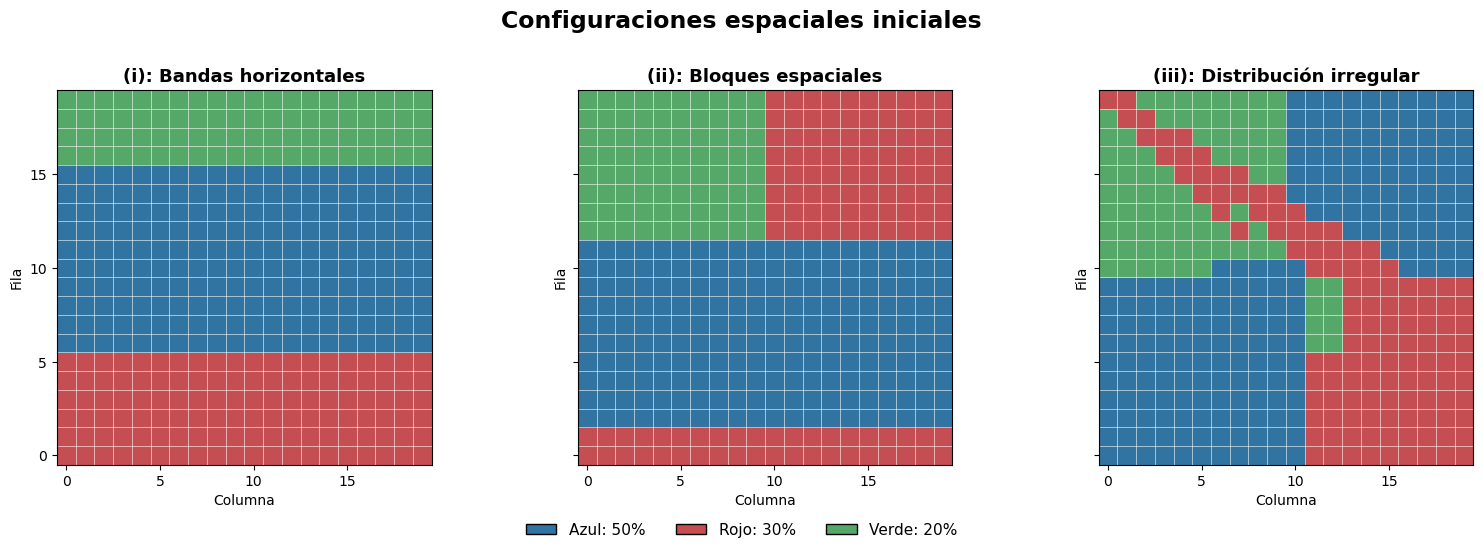

In [19]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5.5),
    sharex=True,
    sharey=True
)

for eje, nombre in zip(
    axes,
    ["(i)", "(ii)", "(iii)"]
):

    eje.imshow(
        matrices_clases[nombre],
        cmap=mapa_colores_clases,
        origin="lower",
        interpolation="nearest",
        vmin=0,
        vmax=2
    )

    nombres_configuraciones = {
        "(i)": "Bandas horizontales",
        "(ii)": "Bloques espaciales",
        "(iii)": "Distribución irregular"
    }

    eje.set_title(
        f"{nombre}: {nombres_configuraciones[nombre]}",
        fontsize=13,
        fontweight="bold"
    )

    eje.set_xlabel("Columna")
    eje.set_ylabel("Fila")

    # Marcas principales cada 5 celdas
    eje.set_xticks(
        np.arange(0, COLUMNAS, 5)
    )

    eje.set_yticks(
        np.arange(0, FILAS, 5)
    )

    # Límites entre todas las celdas
    eje.set_xticks(
        np.arange(-0.5, COLUMNAS, 1),
        minor=True
    )

    eje.set_yticks(
        np.arange(-0.5, FILAS, 1),
        minor=True
    )

    eje.grid(
        which="minor",
        color="white",
        linewidth=0.45,
        alpha=0.9
    )

    eje.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

# Leyenda común
elementos_leyenda = [
    Patch(
        facecolor=COLORES_CLASES[0],
        edgecolor="black",
        label="Azul: 50%"
    ),
    Patch(
        facecolor=COLORES_CLASES[1],
        edgecolor="black",
        label="Rojo: 30%"
    ),
    Patch(
        facecolor=COLORES_CLASES[2],
        edgecolor="black",
        label="Verde: 20%"
    )
]

fig.legend(
    handles=elementos_leyenda,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=11
)

fig.suptitle(
    "Configuraciones espaciales iniciales",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.10, 1, 0.93]
)

plt.show()

In [12]:
#Simulo el camino aleatorio

def simular_caminata(
    G,
    clases,
    nodo_inicial,
    max_pasos,
    rng,
    guardar_recorrido = True
):
    """
    Simula una caminata aleatoria desde nodo_inicial. Retorna:
    - tiempos_encuentro[k]: primer tiempo en que se observaron k clases
    - cantidad_clases_t[t]: cantidadlases observadas hasta el tiempo t
    """
    #Cantidad de clases
    cantidad_total_clases = len(set(clases.values()))

    #Nodo donde arranca el caminante
    nodo_actual = nodo_inicial

    #Empiezo con el recorrido, el primer nodo del recorrido es el inicial
    if guardar_recorrido:
        recorrido = [(nodo_inicial, clases[nodo_inicial])]
    else:
        recorrido = None
        #No guardo el recorrido
    
    #Clase del nodo donde arranca el caminante
    clases_observadas = {
        clases[nodo_actual]
    }

    #Empieza con todos 1s, va reemplazando en el elemento "t" segun la cantidad de clases encontradas en el paso t.
    cantidad_clases_t = np.ones(
        max_pasos + 1,
        dtype = np.int8
    )

    #Cuando se encuentra el caminante con X cantidad de clases?
    tiempos_encuentro = {
        k: None
        for k in range(1,cantidad_total_clases + 1)
    }

    #En t=0 ya conoce 1 clase, la propia:
    tiempos_encuentro[1] = 0

    #Representa la iteracion, los pasos de la caminata que va haciendo la persona
    for tiempo in range(1, max_pasos + 1):

        #vecinos del nodo actual
        vecinos = list(G.neighbors(nodo_actual))

        #Elijo aleatoriamente y equiprobablemente un vecino dentro de la lista de vecinos del nodo actual.
        #Uso "len(vecinos)" porque capaz estoy parado en una celda que tiene 3 vecinos, o en una esquina, con 2.
        indice_elegido = rng.integers(
            low=0,
            high=len(vecinos)
        )

        #Me muevo al nuevo nodo
        nodo_actual = vecinos[indice_elegido]

        #Agrego el nuevo nodo a mi recorrido
        if guardar_recorrido:
            recorrido.append((nodo_actual, clases[nodo_actual]))

        #Agrego la clase del nuevo nodo a mi lista de clases observadas
        clases_observadas.add(
            clases[nodo_actual]
        )

        #Actualizo cantidad de clases
        cantidad_actual = len(clases_observadas)

        #Actualizo el array de cantidad de clases visitadas en cada paso
        cantidad_clases_t[tiempo] = cantidad_actual

        #Si es la primera vez que descubro una nueva clase, en tiempos_encuentro actualizo el tiempo en encontrar X cantidad de clases.
        if tiempos_encuentro[cantidad_actual] is None:
            tiempos_encuentro[cantidad_actual] = tiempo
            # Si es la primera vez que descubro esta clase, actualizo el tiempo
        
        #Ya miré todas las clases, corto la caminata.
        if cantidad_actual == cantidad_total_clases:
            cantidad_clases_t[tiempo:] = cantidad_total_clases
            break

    return tiempos_encuentro, cantidad_clases_t, recorrido

In [ ]:
rng = np.random.default_rng(seed=123)
#Parto desde un mismo nodo y realizo varias iteraciones
nodo_inicial = (5, 10)

for nombre, clases in configuraciones.items():

    rng = np.random.default_rng(seed=123)

    tiempos, cantidad_clases_t, recorrido = simular_caminata(
        G=G,
        clases=clases,
        nodo_inicial=nodo_inicial,
        max_pasos=200,
        rng=rng
    )

    print("\n===================")
    print("Configuración:", nombre)
    print("===================")

    print("Nodo inicial:", nodo_inicial)
    print("Clase inicial:", clases[nodo_inicial])
    print("X2:", tiempos[2])
    print("X3:", tiempos[3])

    print("Primeros 20 valores de c_t:")
    print(cantidad_clases_t[:20])
    print("Resumen de recorrido, primeros 50 nodos:")
    print(recorrido[:50])


Configuración: (i)
Nodo inicial: (5, 10)
Clase inicial: Rojo
X2: 16
X3: 130
Primeros 20 valores de c_t:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2]
Resumen de recorrido, primeros 50 nodos:
[((5, 10), 'Rojo'), ((4, 10), 'Rojo'), ((4, 9), 'Rojo'), ((4, 8), 'Rojo'), ((3, 8), 'Rojo'), ((3, 9), 'Rojo'), ((2, 9), 'Rojo'), ((3, 9), 'Rojo'), ((2, 9), 'Rojo'), ((3, 9), 'Rojo'), ((2, 9), 'Rojo'), ((3, 9), 'Rojo'), ((3, 10), 'Rojo'), ((4, 10), 'Rojo'), ((4, 11), 'Rojo'), ((5, 11), 'Rojo'), ((6, 11), 'Azul'), ((6, 12), 'Azul'), ((6, 13), 'Azul'), ((6, 14), 'Azul'), ((6, 15), 'Azul'), ((5, 15), 'Rojo'), ((5, 14), 'Rojo'), ((6, 14), 'Azul'), ((5, 14), 'Rojo'), ((4, 14), 'Rojo'), ((4, 15), 'Rojo'), ((4, 16), 'Rojo'), ((3, 16), 'Rojo'), ((4, 16), 'Rojo'), ((4, 15), 'Rojo'), ((3, 15), 'Rojo'), ((3, 14), 'Rojo'), ((4, 14), 'Rojo'), ((4, 15), 'Rojo'), ((4, 14), 'Rojo'), ((3, 14), 'Rojo'), ((3, 15), 'Rojo'), ((3, 16), 'Rojo'), ((2, 16), 'Rojo'), ((2, 15), 'Rojo'), ((2, 16), 'Rojo'), ((1, 16), 'Rojo'), ((0,

In [ ]:
#Simulo varias veces desde un mismo nodo origen
numero_simulaciones = 50
max_pasos = 2000
nodo_inicial = (5, 10)
SEMILLA = 123
resultados_todas_configuraciones = []

for nombre_configuracion, clases_configuracion in configuraciones.items():

    cantidad_total_clases = len(set(clases_configuracion.values()))
    # Reinicio el generador al comienzo de este experimento
    rng = np.random.default_rng(seed=SEMILLA)
    for simulacion in range(numero_simulaciones):

        tiempos, cantidad_clases_t, recorrido = simular_caminata(
            G=G,
            clases=clases_configuracion,
            nodo_inicial=nodo_inicial,
            max_pasos=max_pasos,
            rng=rng,
            guardar_recorrido=True
        )

        resultado_simulacion = {
            "configuracion": nombre_configuracion,
            "simulacion": simulacion,
            "nodo_inicial": nodo_inicial,
            "clase_inicial": clases_configuracion[nodo_inicial],
            "cantidad_clases_t": cantidad_clases_t,
            "recorrido": recorrido
        }

        # Guardar todos los X_k
        for k in range(2,cantidad_total_clases + 1):
            resultado_simulacion[f"x{k}"] = tiempos[k]

        resultados_todas_configuraciones.append(resultado_simulacion)

resultados_simulaciones_df = pd.DataFrame(resultados_todas_configuraciones)

#Pongo este codigo para detectar las columnas correspondientes a x_k, 
# como las clases podrian llegar a variar, la cantidad de elementos puede ser dinamica acá
columnas_xk = sorted(
    [
        columna
        for columna in resultados_simulaciones_df.columns
        if columna.startswith("x")
        and columna[1:].isdigit()
    ],
    key=lambda x: int(x[1:])
)

agregaciones = {"simulacion": "size"}

for columna in columnas_xk:
    agregaciones[columna] = ["mean","median","std","min","max"]

resumen = (resultados_simulaciones_df.groupby(["configuracion","clase_inicial"]).agg(agregaciones))
print(resumen)


                            simulacion     x2                             \
                                  size   mean median        std min  max   
configuracion clase_inicial                                                
(i)           Rojo                  50  21.28    7.5  34.527741   1  167   
(ii)          Azul                  50  49.12   38.5  41.307034   5  216   
(iii)         Azul                  50  25.40    9.0  44.205919   1  206   

                                 x3                               
                               mean median         std min   max  
configuracion clase_inicial                                       
(i)           Rojo           434.90  299.0  400.441198  19  1486  
(ii)          Azul           354.44  277.0  310.225077  19  1414  
(iii)         Azul           114.18   47.5  159.862529   2   813  


In [ ]:
#Hago lo mismo que arriba pero defino una funcion para ello
def estimar_tiempos_nodo(
    G,
    clases,
    nodo_inicial,
    numero_simulaciones=100,
    max_pasos=500,
    semilla=123,
    nombre_configuracion = None
):
    """
    Ejecuta muchas caminatas desde un mismo nodo inicial. Calcula estadísticas o metricas como medianas y proporciones de caminatas que no alcanzaron cada objetivo.
    """

    cantidad_total_clases = len(set(clases.values()))

    #Validacion nodo inicial
    if nodo_inicial not in G:
        raise ValueError(
            f"El nodo inicial {nodo_inicial} no pertenece al grafo."
        )

    # Validación nodos sin clase
    nodos_sin_clase = [
        nodo
        for nodo in G.nodes
        if nodo not in clases
    ]
    if len(nodos_sin_clase) > 0:
        raise ValueError(
            f"Hay {len(nodos_sin_clase)} nodos sin clase asignada."
        )

    # Generador aleatorio específico para este nodo
    rng = np.random.default_rng(seed=semilla)

    # Para cada k guardo un tiempo X_k por simulación
    valores_xk = {
        k: []
        for k in range(2,cantidad_total_clases + 1)
    }

    # Repito muchas caminatas desde el mismo origen
    for simulacion in range(numero_simulaciones):

        tiempos, cantidad_clases_t, _ = simular_caminata(
            G=G,
            clases=clases,
            nodo_inicial=nodo_inicial,
            max_pasos=max_pasos,
            rng=rng,
            guardar_recorrido=False
        )

        # Guardar X_k para cada nivel de diversidad
        for k in range(2,cantidad_total_clases + 1):
            if tiempos[k] is None:
                valores_xk[k].append(np.nan)
            else:
                valores_xk[k].append(tiempos[k])

    # lo paso a array
    for k in valores_xk:
        valores_xk[k] = np.asarray(valores_xk[k], dtype=float)

    # Información general del nodo
    resultado = {
    "configuracion":nombre_configuracion,
    "nodo": nodo_inicial,
    "fila": nodo_inicial[0],
    "columna": nodo_inicial[1],
    "clase_inicial": clases[nodo_inicial],
    "simulaciones": numero_simulaciones,
    "max_pasos": max_pasos,
    "cantidad_total_clases": cantidad_total_clases
    }

    # Estadísticas para cada k
    for k, valores in valores_xk.items():
        proporcion_no_alcanzo = np.isnan(valores).mean()
        tiempo_promedio = np.nanmean(valores)
        mediana = np.nanmedian(valores)
        desvio = np.nanstd(valores, ddof=1)
        minimo = np.nanmin(valores)
        maximo = np.nanmax(valores)

        # Columnas dinámicas:
        resultado[f"t{k}"] = tiempo_promedio
        resultado[f"mediana_x{k}"] = mediana
        resultado[f"desvio_x{k}"] = desvio
        resultado[f"minimo_x{k}"] = minimo
        resultado[f"maximo_x{k}"] = maximo
        resultado[f"no_alcanzo_{k}"] = proporcion_no_alcanzo

    return resultado, valores_xk

In [86]:
#Hago el experimento partiendo de todos los nodos ahora.
nodos_iniciales = list(G.nodes)
numero_simulaciones_por_nodo = 200
max_pasos = 2000
SEMILLA_BASE = 42
resultados_origenes_lista = []
valores_xk_por_configuracion = {}

for numero_configuracion, (nombre_configuracion, clases_configuracion) in enumerate(configuraciones.items()):

    cantidad_total_clases = len(set(clases_configuracion.values()))

    # Diccionario interno para los X_k de esta configuración
    valores_xk_por_configuracion[nombre_configuracion] = {}

    for posicion, nodo_inicial in enumerate(nodos_iniciales):

        # Semilla única para cada combinación y configuración x nodo
        semilla_nodo = (SEMILLA_BASE + numero_configuracion * G.number_of_nodes() + posicion)

        resultado, valores_xk = estimar_tiempos_nodo(
            G=G,
            clases=clases_configuracion,
            nodo_inicial=nodo_inicial,
            numero_simulaciones=numero_simulaciones_por_nodo,
            max_pasos=max_pasos,
            semilla=semilla_nodo,
            nombre_configuracion=nombre_configuracion
        )

        # Guardar fila resumen
        resultados_origenes_lista.append(resultado)

        # Guardar todos los X_k del nodo
        valores_xk_por_configuracion[nombre_configuracion][nodo_inicial] = valores_xk

resultados_origenes = pd.DataFrame(resultados_origenes_lista)
print("Dimensiones:", resultados_origenes.shape)
print(resultados_origenes.head())
print(valores_xk_por_configuracion['(iii)'][(3,7)]) #por ejemplo, ver los x_2 y x_3 para el nodo inicial (3,7) en la configuracion iii.

Dimensiones: (1200, 20)
  configuracion    nodo  fila  columna clase_inicial  simulaciones  max_pasos  \
0           (i)  (0, 0)     0        0          Rojo           200       2000   
1           (i)  (0, 1)     0        1          Rojo           200       2000   
2           (i)  (0, 2)     0        2          Rojo           200       2000   
3           (i)  (0, 3)     0        3          Rojo           200       2000   
4           (i)  (0, 4)     0        4          Rojo           200       2000   

   cantidad_total_clases      t2  mediana_x2  desvio_x2  minimo_x2  maximo_x2  \
0                      3  80.540        62.0  66.545774        7.0      404.0   
1                      3  75.715        59.0  60.339523        8.0      381.0   
2                      3  77.920        60.5  63.564027        9.0      354.0   
3                      3  79.700        57.0  68.340266       10.0      360.0   
4                      3  64.100        48.0  48.981280        9.0      284.0   

  

In [87]:
#Miro algunas columnas
columnas_tk = sorted(
    [
        columna
        for columna in resultados_origenes.columns
        if columna.startswith("t")
        and columna[1:].isdigit()
    ],
    key=lambda columna: int(
        columna[1:]
    )
)

columnas_no_alcanzo = [
    f"no_alcanzo_{columna[1:]}"
    for columna in columnas_tk
]


columnas_mostrar = (
    [
        "configuracion",
        "nodo",
        "fila",
        "columna",
        "clase_inicial"
    ]
    + columnas_tk
    + columnas_no_alcanzo
)

print(
    resultados_origenes[
        columnas_mostrar
    ].head(20)
)

   configuracion     nodo  fila  columna clase_inicial      t2          t3  \
0            (i)   (0, 0)     0        0          Rojo  80.540  498.125628   
1            (i)   (0, 1)     0        1          Rojo  75.715  532.732323   
2            (i)   (0, 2)     0        2          Rojo  77.920  494.400000   
3            (i)   (0, 3)     0        3          Rojo  79.700  500.954315   
4            (i)   (0, 4)     0        4          Rojo  64.100  478.718593   
5            (i)   (0, 5)     0        5          Rojo  71.920  475.025126   
6            (i)   (0, 6)     0        6          Rojo  74.995  515.419192   
7            (i)   (0, 7)     0        7          Rojo  76.390  537.051020   
8            (i)   (0, 8)     0        8          Rojo  77.490  478.090909   
9            (i)   (0, 9)     0        9          Rojo  82.610  462.832487   
10           (i)  (0, 10)     0       10          Rojo  74.750  510.151515   
11           (i)  (0, 11)     0       11          Rojo  77.665  

In [88]:
#Miro mayores y menores tiempos de t2 por configuracion
nodos_menor_t2 = (resultados_origenes.sort_values("t2").groupby("configuracion",group_keys=False).head(5))

print(nodos_menor_t2[["configuracion","nodo","clase_inicial"] + columnas_tk])

nodos_mayor_t2 = (resultados_origenes.sort_values("t2",ascending=False).groupby("configuracion",group_keys=False).head(5))

print(nodos_mayor_t2[["configuracion","nodo","clase_inicial"] + columnas_tk])

     configuracion      nodo clase_inicial      t2          t3
1067         (iii)   (13, 7)         Verde   1.000   39.960000
1047         (iii)   (12, 7)          Rojo   1.000   31.900000
1029         (iii)   (11, 9)         Verde   1.550   24.810000
1048         (iii)   (12, 8)         Verde   1.810   30.675000
1066         (iii)   (13, 6)          Rojo   1.880   49.075000
439           (ii)   (1, 19)          Rojo   5.320  432.055556
650           (ii)  (12, 10)          Rojo   5.710  129.860000
649           (ii)   (12, 9)         Verde   5.760   74.760000
421           (ii)    (1, 1)          Rojo   6.200  344.235000
431           (ii)   (1, 11)          Rojo   6.305  446.954774
338            (i)  (16, 18)         Verde  11.810  366.835000
333            (i)  (16, 13)         Verde  12.510  399.875000
321            (i)   (16, 1)         Verde  12.670  357.600000
324            (i)   (16, 4)         Verde  13.610  375.850000
326            (i)   (16, 6)         Verde  13.770  407

In [89]:
#Estadisticas por clase

resumenes = []

for (nombre_configuracion,clase), datos_grupo in resultados_origenes.groupby(["configuracion","clase_inicial"]):

    fila_resumen = {
        "configuracion": nombre_configuracion,
        "clase_inicial": clase,
        "nodos_analizados": len(datos_grupo)
    }

    for columna in columnas_tk:

        k = int(columna.replace("t",""))
        fila_resumen[f"t{k}_promedio"] = datos_grupo[columna].mean()
        fila_resumen[f"t{k}_mediana"] = datos_grupo[columna].median()
        fila_resumen[f"t{k}_desvio_entre_nodos"] = datos_grupo[columna].std()
        fila_resumen[f"t{k}_minimo"] = datos_grupo[columna].min()
        fila_resumen[f"t{k}_maximo"] = datos_grupo[columna].max()
        fila_resumen[f"no_alcanzo_{k}_promedio"] = datos_grupo[f"no_alcanzo_{k}"].mean()

    resumenes.append(fila_resumen)

resumen_por_configuracion_clase = pd.DataFrame(resumenes)
print(resumen_por_configuracion_clase)

#Estadistica Global
resumenes_globales = []

for (nombre_configuracion, datos_configuracion) in resultados_origenes.groupby("configuracion"):

    fila_resumen = {"configuracion": nombre_configuracion, 
                    "nodos_analizados": len(datos_configuracion)}

    for columna in columnas_tk:

        k = int(columna[1:])
        fila_resumen[f"t{k}_promedio_global"] = datos_configuracion[columna].mean()
        fila_resumen[f"t{k}_mediana_global"] = datos_configuracion[columna].median()
        fila_resumen[f"t{k}_desvio_global"] = datos_configuracion[columna].std()

    resumenes_globales.append(fila_resumen)

resumen_por_configuracion = pd.DataFrame(resumenes_globales)
print(resumen_por_configuracion)

  configuracion clase_inicial  nodos_analizados  t2_promedio  t2_mediana  \
0           (i)          Azul               200    43.232775     46.2450   
1           (i)          Rojo               120    56.080958     61.0725   
2           (i)         Verde                80    26.804062     28.2450   
3          (ii)          Azul               200    43.025725     47.0100   
4          (ii)          Rojo               120    36.109208     26.3025   
5          (ii)         Verde                80    50.506375     53.3300   
6         (iii)          Azul               200    62.864475     62.1750   
7         (iii)          Rojo               120    37.990250     33.9950   
8         (iii)         Verde                80    10.317250      9.1975   

   t2_desvio_entre_nodos  t2_minimo  t2_maximo  no_alcanzo_2_promedio  \
0              14.508496     14.900     66.295                    0.0   
1              19.307645     16.610     85.615                    0.0   
2               8.20

In [90]:
# Unpivot de las columnas t2, t3, ..., tK
resultados_largos = resultados_origenes.melt(
    id_vars=[
        "configuracion",
        "nodo",
        "fila",
        "columna",
        "clase_inicial"
    ],
    value_vars=columnas_tk,
    var_name="nivel_diversidad",
    value_name="tiempo_esperado"
)

# Convertir "t2", "t3", etc. en 2, 3, etc.
resultados_largos["k"] = (resultados_largos["nivel_diversidad"].str.replace("t", "", regex=False).astype(int))

colores = {"Azul": "#3274A1","Rojo": "#C44E52","Verde": "#55A868"}
orden_configuraciones = ["(i)","(ii)","(iii)"]
nombres_configuraciones = {"(i)": "Bandas horizontales","(ii)": "Bloques espaciales","(iii)": "Distribución irregular"}

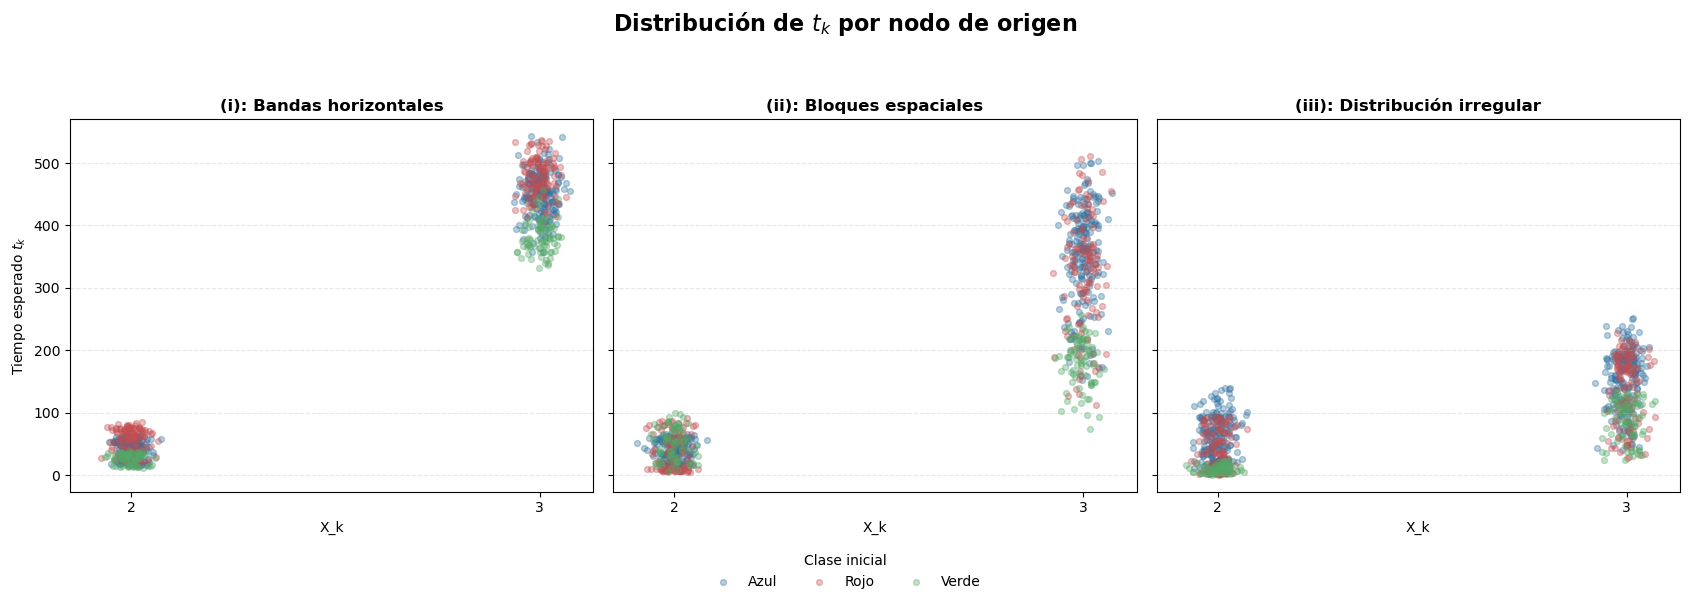

In [91]:
rng_jitter = np.random.default_rng(seed=42)
fig, axes = plt.subplots(1,3,figsize=(17, 6),sharex=True,sharey=True)

for eje, configuracion in zip(axes,orden_configuraciones):

    datos_configuracion = resultados_largos.loc[resultados_largos["configuracion"] == configuracion].copy()

    for clase, datos_clase in datos_configuracion.groupby("clase_inicial"):

        desplazamiento = rng_jitter.normal(loc=0,scale=0.025,size=len(datos_clase))
        eje.scatter(
            datos_clase["k"] + desplazamiento,
            datos_clase["tiempo_esperado"],
            color=colores[clase],
            alpha=0.35,
            s=18,
            label=clase
        )
    eje.set_title(
        f"{configuracion}: "
        f"{nombres_configuraciones[configuracion]}",
        fontweight="bold"
    )
    eje.set_xlabel("X_k")
    eje.set_xticks(sorted(resultados_largos["k"].unique()))
    eje.grid(axis="y",linestyle="--",alpha=0.30)

axes[0].set_ylabel(r"Tiempo esperado $t_k$")
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Clase inicial",
    loc="lower center",
    ncol=3,
    frameon=False
)

fig.suptitle(r"Distribución de $t_k$ por nodo de origen",fontsize=16,fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

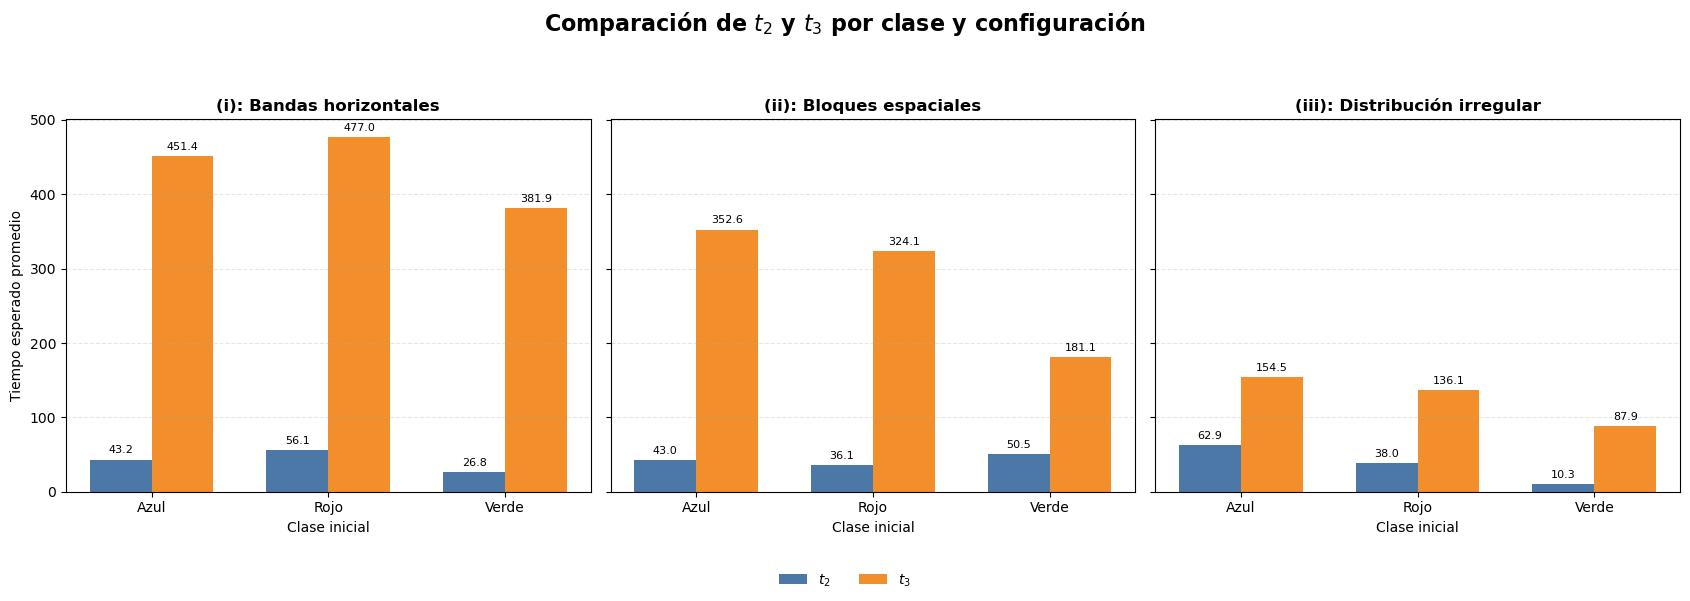

In [92]:
resumen_clase_k = (
    resultados_largos.groupby(["configuracion","clase_inicial","k"],as_index=False)
    .agg(
        tiempo_promedio=("tiempo_esperado","mean"),
        tiempo_mediano=("tiempo_esperado","median"),
        desvio_entre_nodos=("tiempo_esperado","std"),
        cantidad_nodos=("nodo","size")
    )
)

fig, axes = plt.subplots(1,3,figsize=(17, 6),sharey=True)
orden_clases = ["Azul","Rojo","Verde"]
ancho = 0.35
posiciones = np.arange(len(orden_clases))
for eje, configuracion in zip(axes,orden_configuraciones):

    datos_configuracion = resumen_clase_k.loc[resumen_clase_k["configuracion"] == configuracion]
    valores_t2 = []
    valores_t3 = []
    for clase in orden_clases:

        valor_t2 = datos_configuracion.loc[(datos_configuracion["clase_inicial"] == clase) & 
                                           ( datos_configuracion["k"] == 2),"tiempo_promedio"].iloc[0]
        valor_t3 = datos_configuracion.loc[(datos_configuracion["clase_inicial"] == clase)
                                         & (datos_configuracion["k"] == 3),"tiempo_promedio"].iloc[0]
        valores_t2.append(valor_t2)
        valores_t3.append(valor_t3)

    bars_t2 = eje.bar(posiciones - ancho / 2,valores_t2,width=ancho,label=r"$t_2$",color="#4C78A8")
    bars_t3 = eje.bar(posiciones + ancho / 2,valores_t3,width=ancho,label=r"$t_3$",color="#F28E2B")
    eje.bar_label(bars_t2,fmt="%.1f",padding=3,fontsize=8)
    eje.bar_label(bars_t3,fmt="%.1f",padding=3,fontsize=8)
    eje.set_xticks(posiciones)
    eje.set_xticklabels(orden_clases)
    eje.set_title(f"{configuracion}: "f"{nombres_configuraciones[configuracion]}",fontweight="bold")
    eje.set_xlabel("Clase inicial")
    eje.grid(axis="y",linestyle="--",alpha=0.30)

axes[0].set_ylabel("Tiempo esperado promedio")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.suptitle(r"Comparación de $t_2$ y $t_3$ por clase y configuración",fontsize=16,fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

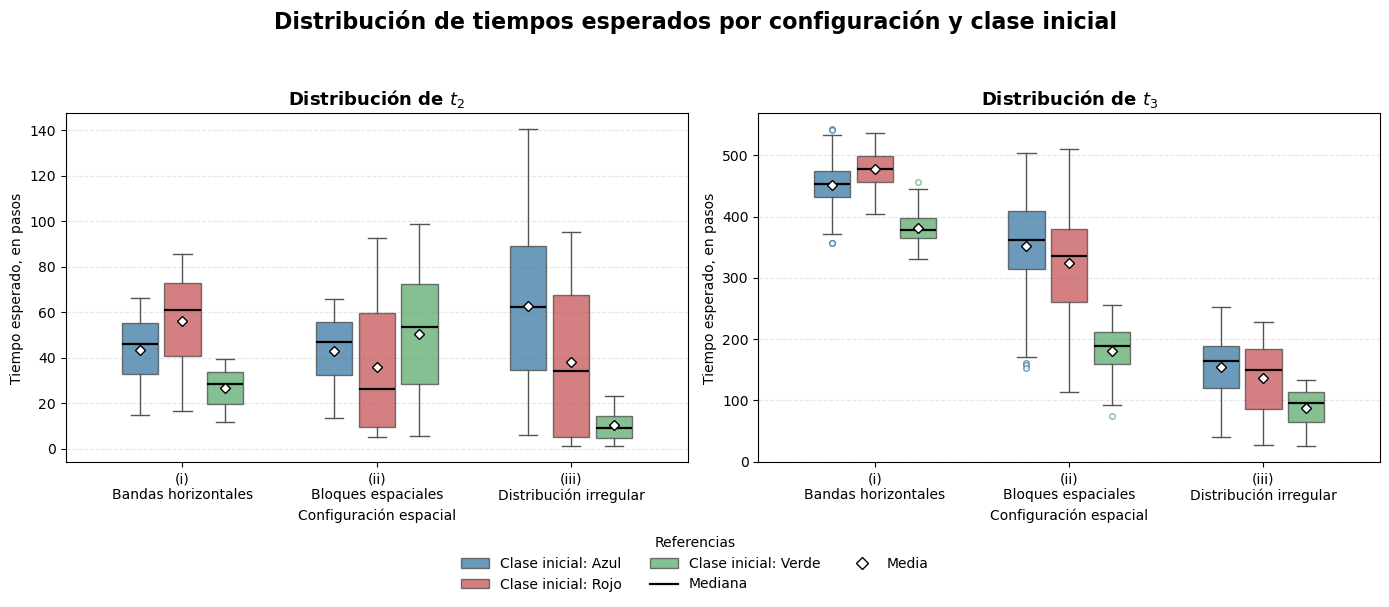

In [93]:
colores_clases = {
    "Azul": "#3274A1",
    "Rojo": "#C44E52",
    "Verde": "#55A868"
}

fig, axes = plt.subplots(nrows=1,ncols=len(columnas_tk),figsize=(7 * len(columnas_tk), 6),sharey=False)
ancho_caja = 0.22
posiciones_configuracion = np.arange(len(orden_configuraciones))
desplazamientos = {"Azul": -ancho_caja,"Rojo": 0,"Verde": ancho_caja}

for posicion_grafico, columna_tk in enumerate(columnas_tk):

    ax = axes[posicion_grafico]

    for clase in orden_clases:

        datos_clase = []
        posiciones_clase = []

        for indice_configuracion, configuracion in enumerate(orden_configuraciones):

            valores = resultados_origenes.loc[( resultados_origenes["configuracion"] == configuracion)
                & (resultados_origenes["clase_inicial"] == clase),columna_tk].dropna().to_numpy()
            datos_clase.append(valores)
            posiciones_clase.append(posiciones_configuracion[indice_configuracion] + desplazamientos[clase])

        bp = ax.boxplot(
            datos_clase,
            positions=posiciones_clase,
            widths=ancho_caja * 0.85,
            patch_artist=True,
            showmeans=True,

            # Mediana
            medianprops={"color": "black","linewidth": 1.6},
            # Media
            meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 5},
            # Bigotes
            whiskerprops={"color": "#555555","linewidth": 1},
            # Límites de los bigotes
            capprops={"color": "#555555","linewidth": 1},
            # Valores atípicos
            flierprops={"marker": "o","markerfacecolor": "white","markeredgecolor": colores_clases[clase],"markersize": 4,"alpha": 0.7}
        )

        # Dar a todas las cajas de esta iteración
        # el color correspondiente a la clase
        for caja in bp["boxes"]:
            caja.set_facecolor(colores_clases[clase])
            caja.set_edgecolor("#444444")
            caja.set_alpha(0.72)

    ax.set_title(rf"Distribución de $t_{{{columna_tk[1:]}}}$",fontsize=13,fontweight="bold")
    ax.set_xlabel("Configuración espacial")
    ax.set_ylabel("Tiempo esperado, en pasos")
    ax.set_xticks(posiciones_configuracion)
    ax.set_xticklabels([f"{configuracion}\n"f"{nombres_configuraciones[configuracion]}" for configuracion in orden_configuraciones])
    ax.grid(axis="y",linestyle="--",alpha=0.30)
    ax.set_xlim( -0.6, len(orden_configuraciones) - 0.4)

# Leyenda: el color identifica la clase inicial
elementos_leyenda = [
    Patch(
        facecolor=colores_clases["Azul"],
        edgecolor="#444444",
        alpha=0.72,
        label="Clase inicial: Azul"
    ),
    Patch(
        facecolor=colores_clases["Rojo"],
        edgecolor="#444444",
        alpha=0.72,
        label="Clase inicial: Rojo"
    ),
    Patch(
        facecolor=colores_clases["Verde"],
        edgecolor="#444444",
        alpha=0.72,
        label="Clase inicial: Verde"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.6,
        label="Mediana"
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="None",
        markersize=6,
        label="Media"
    )
]

fig.legend(
    handles=elementos_leyenda,
    title="Referencias",
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

fig.suptitle("Distribución de tiempos esperados por configuración y clase inicial",fontsize=16,fontweight="bold")
plt.tight_layout(rect=[0, 0.10, 1, 0.94])
plt.show()

In [94]:
def resultados_a_matriz(
    resultados,
    configuracion,
    variable,
    filas,
    columnas
):
    matriz = np.full((filas, columnas),np.nan)
    datos_configuracion = resultados.loc[resultados["configuracion"] == configuracion]

    for _, registro in datos_configuracion.iterrows():

        fila, columna = registro["nodo"]
        matriz[fila, columna] = registro[variable]

    return matriz

matrices_t2 = {}
matrices_t3 = {}

for configuracion in orden_configuraciones:

    matrices_t2[configuracion] = resultados_a_matriz(
        resultados=resultados_origenes,
        configuracion=configuracion,
        variable="t2",
        filas=FILAS,
        columnas=COLUMNAS
    )

    matrices_t3[configuracion] = resultados_a_matriz(
        resultados=resultados_origenes,
        configuracion=configuracion,
        variable="t3",
        filas=FILAS,
        columnas=COLUMNAS
    )

vmin_t2 = min(
    np.nanmin(matriz)
    for matriz in matrices_t2.values()
)

vmax_t2 = max(
    np.nanmax(matriz)
    for matriz in matrices_t2.values()
)

vmin_t3 = min(
    np.nanmin(matriz)
    for matriz in matrices_t3.values()
)

vmax_t3 = max(
    np.nanmax(matriz)
    for matriz in matrices_t3.values()
)

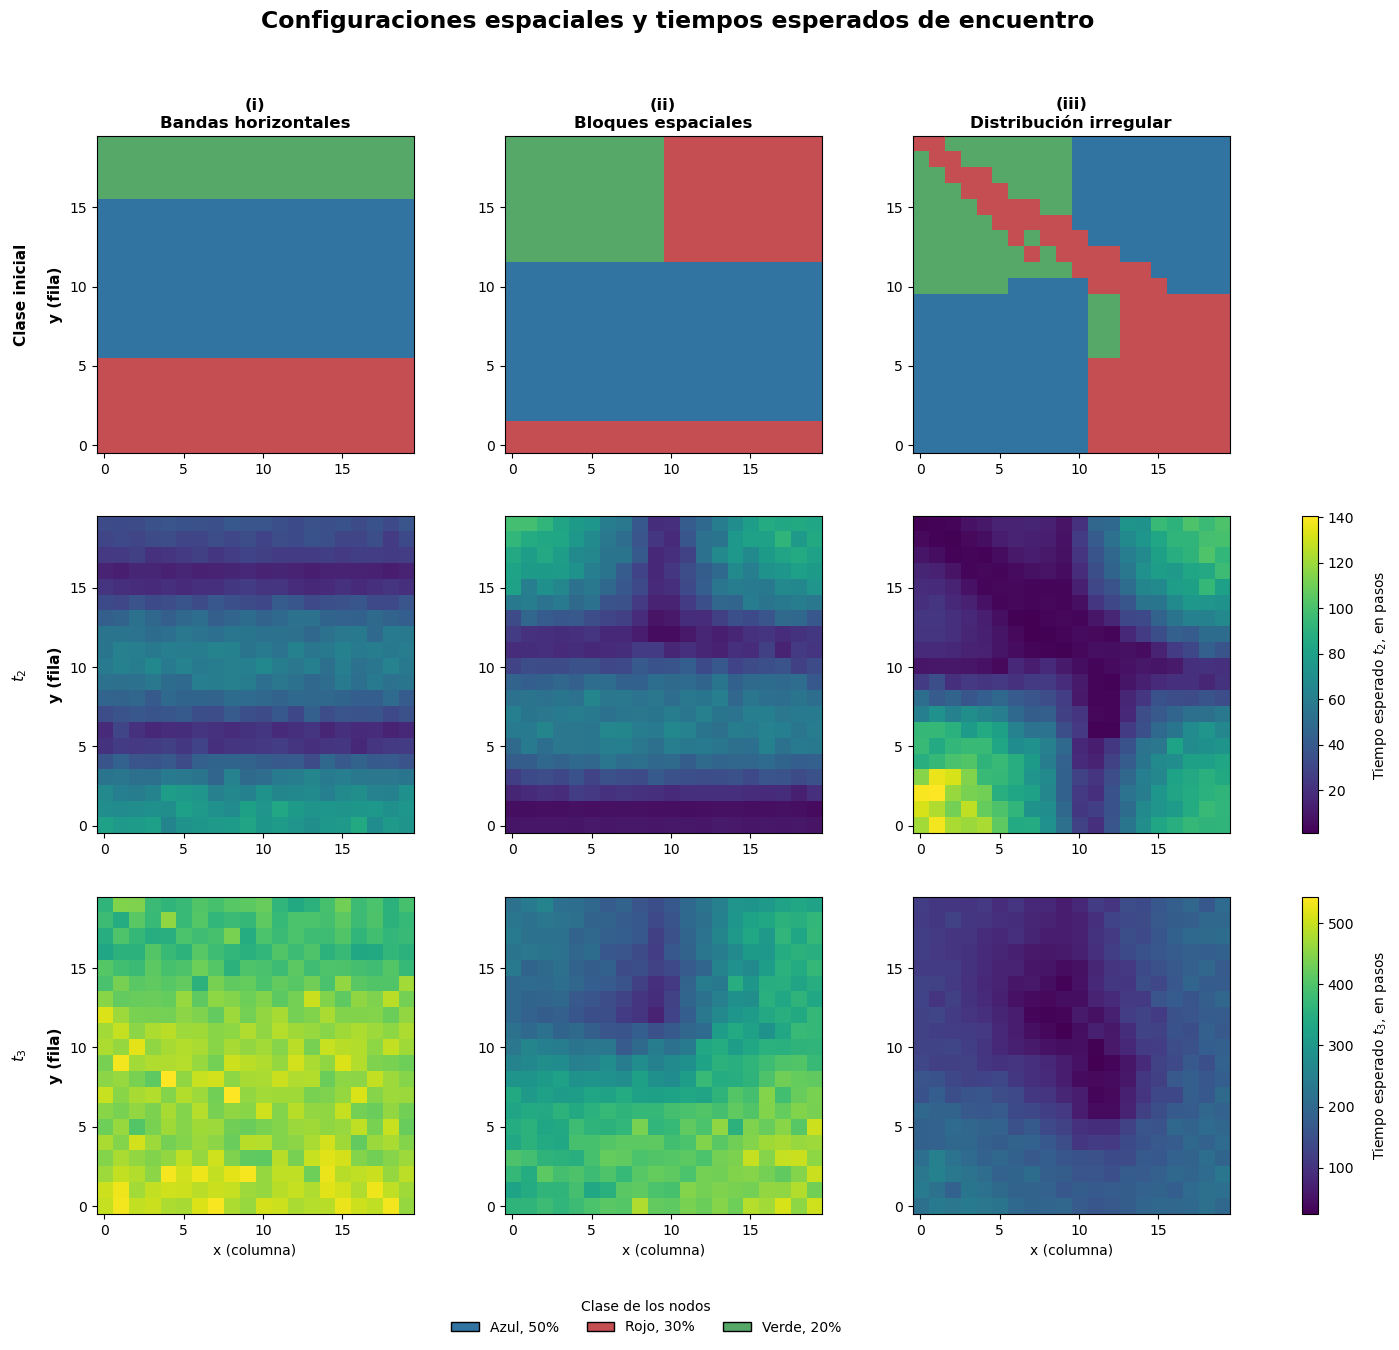

In [99]:
fig = plt.figure(figsize=(16, 14))

# La cuarta columna queda reservada para las barras de color
gs = fig.add_gridspec(
    nrows=3,
    ncols=4,
    width_ratios=[1,1,1,0.045],
    height_ratios=[1,1,1],
    wspace=0.20,
    hspace=0.20
)

# Matriz de ejes para los nueve mapas
axes = np.empty((3, 3),dtype=object)
for fila in range(3):
    for columna in range(3):
        axes[fila, columna] = fig.add_subplot(
            gs[fila, columna], 
            sharex=axes[0, 0] if fila > 0 or columna > 0 else None,
            sharey=axes[0, 0] if fila > 0 or columna > 0 else None
        )

# Ejes exclusivos para las barras de color
cax_t2 = fig.add_subplot(gs[1, 3])
cax_t3 = fig.add_subplot(gs[2, 3])
imagen_t2 = None
imagen_t3 = None

for columna_grafico, configuracion in enumerate(orden_configuraciones):

    axes[0,columna_grafico].imshow(
        matrices_clases[configuracion],
        origin="lower",
        cmap=mapa_colores_clases,
        interpolation="nearest",
        vmin=0,
        vmax=2
    )

    axes[0,columna_grafico].set_title(f"{configuracion}\n"f"{nombres_configuraciones[configuracion]}",fontsize=12,fontweight="bold")

    imagen_t2 = axes[1,columna_grafico].imshow(
        matrices_t2[configuracion],
        origin="lower",
        cmap="viridis",
        interpolation="nearest",
        vmin=vmin_t2,
        vmax=vmax_t2
    )

    imagen_t3 = axes[2,columna_grafico].imshow(
        matrices_t3[configuracion],
        origin="lower",
        cmap="viridis",
        interpolation="nearest",
        vmin=vmin_t3,
        vmax=vmax_t3
    )
    # Etiqueta X solamente en la última fila
    axes[2,columna_grafico].set_xlabel("x (columna)")

    # Marcas comunes
    for fila_grafico in range(3):

        axes[fila_grafico,columna_grafico].set_xticks(np.arange(0,COLUMNAS,5))
        axes[fila_grafico,columna_grafico].set_yticks(np.arange(0,FILAS,5))

axes[0, 0].set_ylabel("Clase inicial\n\ny (fila)",fontsize=11,fontweight="bold")
axes[1, 0].set_ylabel(r"$t_2$""\n\ny (fila)",fontsize=11,fontweight="bold")
axes[2, 0].set_ylabel(r"$t_3$""\n\ny (fila)",fontsize=11,fontweight="bold")

#Barras de color
barra_t2 = fig.colorbar(imagen_t2,cax=cax_t2)
barra_t2.set_label(r"Tiempo esperado $t_2$, en pasos",rotation=90,labelpad=12)
barra_t3 = fig.colorbar(imagen_t3,cax=cax_t3)
barra_t3.set_label(r"Tiempo esperado $t_3$, en pasos",rotation=90,labelpad=12)

# Leyenda para las clases
leyenda_clases = [Patch(facecolor=COLORES_CLASES[0],edgecolor="black",label="Azul, 50%"),
                  Patch(facecolor=COLORES_CLASES[1],edgecolor="black",label="Rojo, 30%"),
                  Patch(facecolor=COLORES_CLASES[2],edgecolor="black",label="Verde, 20%")]

fig.legend(handles=leyenda_clases,title="Clase de los nodos",loc="lower center",ncol=3,frameon=False,bbox_to_anchor=(0.48, 0.015))

# Título general
fig.suptitle("Configuraciones espaciales y tiempos esperados de encuentro",fontsize=17,fontweight="bold",y=0.97)
plt.show()

In [ ]:
#Dejo esta celda libre para calculo de eff_t luego